# AI-Powered Personal Spending & Financial Behavior Coach
## Notebook 05 — Modeling (High-Spender Classification)

### Objective
Develop and evaluate 2–3 supervised models that predict whether a transaction is a "High Spender" transaction.

Because this dataset contains one transaction per customer, a supervised classification task is the most appropriate modeling approach.

We will:
1. Define a binary target: High Spender = top 25% transaction amount
2. Build a modeling pipeline with preprocessing (encoding + scaling as needed)
3. Fit and evaluate multiple models
4. Tune hyperparameters for at least one model
5. Select a final model to support deployment and LLM-based coaching

## 0) Imports

We import libraries for modeling, evaluation metrics, and hyperparameter tuning.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

## 1) Load Data

We load the cleaned transactions dataset from the wrangling stage.
We confirm expected columns exist and prepare for target creation.

In [7]:
df = pd.read_csv("cleaned_transactions.csv")

# Ensure expected columns exist (adjust if your cleaned file uses different names)
expected = {"customer_id", "transaction_amount", "category", "gender", "age"}
missing = expected - set(df.columns)
if missing:
    print("Missing expected columns:", missing)

df.head()

,customer_id,name,surname,gender,birthdate,transaction_amount,date,merchant_name,category,merchant_name_clean,year,month,day,weekday,age,age_group
0,752858,Sean,Rodriguez,F,2002-10-20,35.47,2023-04-03,Smith-Russell,Cosmetic,smith russell,2023,4,3,Monday,23,18-25
1,26381,Michelle,Phelps,Unknown,1985-10-24,2552.72,2023-07-17,"Peck, Spence and Young",Travel,peck spence and young,2023,7,17,Monday,40,36-45
2,305449,Jacob,Williams,M,1981-10-25,115.97,2023-09-20,Steele Inc,Clothing,steele inc,2023,9,20,Wednesday,44,36-45
3,988259,Nathan,Snyder,M,1977-10-26,11.31,2023-01-11,"Wilson, Wilson and Russell",Cosmetic,wilson wilson and russell,2023,1,11,Wednesday,48,46-55
4,764762,Crystal,Knapp,F,1951-11-02,62.21,2023-06-13,Palmer-Hinton,Electronics,palmer hinton,2023,6,13,Tuesday,74,65+


## 2) Define the Response Variable (Target)

Target definition:
- `high_spender = 1` if transaction_amount is in the top 25% (>= 75th percentile)
- `high_spender = 0` otherwise

This creates a meaningful classification objective aligned with:
- Spending intensity segmentation
- Risk/overspending flags
- "Coaching trigger" for the LLM layer

In [10]:
threshold = df["transaction_amount"].quantile(0.75)
df["high_spender"] = (df["transaction_amount"] >= threshold).astype(int)

df["high_spender"].value_counts(), threshold

(high_spender
 0    37500
 1    12500
 Name: count, dtype: int64,
 470.515)

## 3) Feature Selection

We avoid data leakage by **excluding** transaction_amount from predictors,
since it is used to define the target.

Predictors included:
- age (numeric)
- gender (categorical; includes "Unknown")
- category (categorical)
- merchant_name_clean (categorical, optional but often helpful)

If merchant_name_clean is not available, we fall back to merchant_name.

In [13]:
merchant_col = "merchant_name_clean" if "merchant_name_clean" in df.columns else ("merchant_name" if "merchant_name" in df.columns else None)

feature_cols = ["age", "gender", "category"]
if merchant_col:
    feature_cols.append(merchant_col)

X = df[feature_cols].copy()
y = df["high_spender"].copy()

X.head()

,age,gender,category,merchant_name_clean
0,23,F,Cosmetic,smith russell
1,40,Unknown,Travel,peck spence and young
2,44,M,Clothing,steele inc
3,48,M,Cosmetic,wilson wilson and russell
4,74,F,Electronics,palmer hinton


## 4) Train/Test Split

We split into training and test sets:
- 80% train
- 20% test
- stratified by the target to preserve class balance

This supports fair out-of-sample evaluation.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train target rate:", y_train.mean().round(3), " Test target rate:", y_test.mean().round(3))

Train: (40000, 4)  Test: (10000, 4)
Train target rate: 0.25  Test target rate: 0.25


## 5) Preprocessing for Modeling

We build a reusable preprocessing pipeline:
- One-hot encode categorical variables
- Scale numeric variables (helps Logistic Regression)
- Keep everything inside a single Pipeline for reproducibility

In [26]:
numeric_features = ["age"]
categorical_features = [c for c in feature_cols if c not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop"
)

categorical_features

['gender', 'category', 'merchant_name_clean']

## 6) Model 1 — Logistic Regression (Baseline)

Logistic Regression provides:
- strong baseline performance
- interpretability (feature weights)
- fast training

We evaluate using:
- ROC AUC (primary)
- classification report (precision/recall/F1)
- confusion matrix

In [29]:
log_reg = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

log_reg.fit(X_train, y_train)

proba = log_reg.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("Logistic Regression — ROC AUC:", roc_auc_score(y_test, proba).round(4))
print(classification_report(y_test, pred))
print("Confusion matrix:\n", confusion_matrix(y_test, pred))

Logistic Regression — ROC AUC: 0.9557
              precision    recall  f1-score   support

           0       0.98      0.89      0.93      7500
           1       0.74      0.94      0.83      2500

    accuracy                           0.90     10000
   macro avg       0.86      0.91      0.88     10000
weighted avg       0.92      0.90      0.90     10000

Confusion matrix:
 [[6667  833]
 [ 159 2341]]


### ROC Curve (Logistic Regression)

ROC curve visualizes TPR vs FPR across thresholds.
AUC closer to 1 indicates stronger ranking performance.

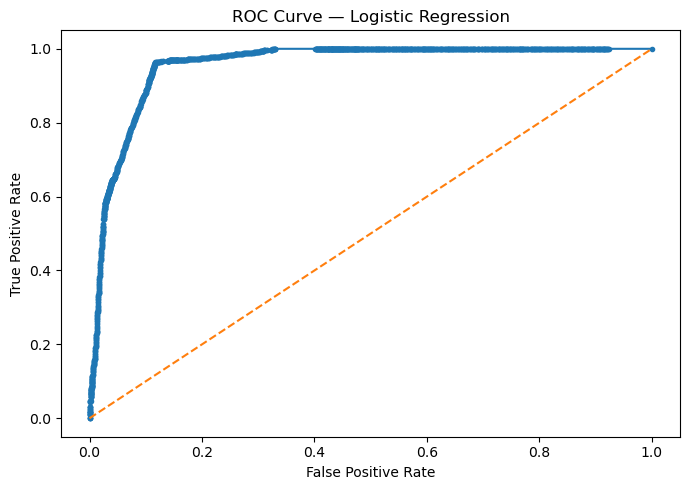

In [32]:
fpr, tpr, _ = roc_curve(y_test, proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, marker=".")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve — Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()
plt.show()

## 7) Model 2 — Random Forest

Random Forest can capture non-linear relationships and interactions.
It also provides feature importance for interpretation.

Note:
Trees do not require scaling, but we keep preprocessing consistent for reproducibility.

In [35]:
rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)

rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred = (rf_proba >= 0.5).astype(int)

print("Random Forest — ROC AUC:", roc_auc_score(y_test, rf_proba).round(4))
print(classification_report(y_test, rf_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, rf_pred))

Random Forest — ROC AUC: 0.9514
              precision    recall  f1-score   support

           0       0.98      0.89      0.93      7500
           1       0.73      0.95      0.83      2500

    accuracy                           0.90     10000
   macro avg       0.86      0.92      0.88     10000
weighted avg       0.92      0.90      0.91     10000

Confusion matrix:
 [[6639  861]
 [ 126 2374]]


## 8) Model 3 — Gradient Boosting

Gradient Boosting typically performs well on structured tabular data.
It can outperform Random Forest depending on the dataset.

We evaluate with the same metrics for fair comparison.

In [38]:
gb = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

gb.fit(X_train, y_train)

gb_proba = gb.predict_proba(X_test)[:, 1]
gb_pred = (gb_proba >= 0.5).astype(int)

print("Gradient Boosting — ROC AUC:", roc_auc_score(y_test, gb_proba).round(4))
print(classification_report(y_test, gb_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, gb_pred))

Gradient Boosting — ROC AUC: 0.9566
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      7500
           1       0.73      0.96      0.83      2500

    accuracy                           0.90     10000
   macro avg       0.86      0.92      0.88     10000
weighted avg       0.92      0.90      0.91     10000

Confusion matrix:
 [[6628  872]
 [  95 2405]]


## 9) Hyperparameter Tuning (Grid Search)

We tune the Random Forest model as a representative example.

We search:
- n_estimators
- max_depth
- min_samples_split

Metric:
- ROC AUC

In [41]:
rf_tune = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 8, 12],
    "model__min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    rf_tune,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV ROC AUC:", round(grid.best_score_, 4))

Best params: {'model__max_depth': 12, 'model__min_samples_split': 10, 'model__n_estimators': 400}
Best CV ROC AUC: 0.951


### Evaluate Tuned Random Forest on Test Set

We compare tuned model performance against earlier models using ROC AUC and the classification report.

In [44]:
best_rf = grid.best_estimator_

best_proba = best_rf.predict_proba(X_test)[:, 1]
best_pred = (best_proba >= 0.5).astype(int)

print("Tuned Random Forest — Test ROC AUC:", roc_auc_score(y_test, best_proba).round(4))
print(classification_report(y_test, best_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, best_pred))

Tuned Random Forest — Test ROC AUC: 0.947
              precision    recall  f1-score   support

           0       0.75      1.00      0.86      7500
           1       0.00      0.00      0.00      2500

    accuracy                           0.75     10000
   macro avg       0.38      0.50      0.43     10000
weighted avg       0.56      0.75      0.64     10000

Confusion matrix:
 [[7500    0]
 [2500    0]]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 10) Feature Importance (Deployment Insight)

Feature importance helps:
- explain model behavior
- guide LLM coaching prompts (“Top drivers for this prediction…”)
- provide transparency for end-users

We extract feature names from preprocessing + importance from the tuned RF.

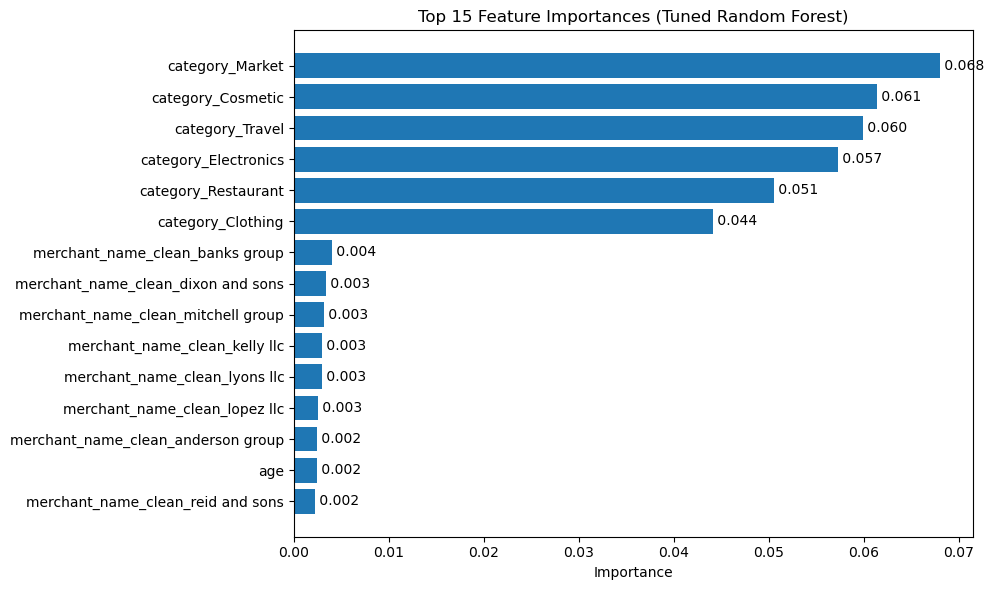

,feature,importance
7,category_Market,0.068073
5,category_Cosmetic,0.061426
9,category_Travel,0.059949
6,category_Electronics,0.057247
8,category_Restaurant,0.050578
4,category_Clothing,0.044146
1324,merchant_name_clean_banks group,0.004018
6560,merchant_name_clean_dixon and sons,0.003418
17950,merchant_name_clean_mitchell group,0.003122
14109,merchant_name_clean_kelly llc,0.002998


In [47]:
# Get feature names after one-hot encoding
ohe = best_rf.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)

feature_names = np.concatenate([numeric_features, cat_feature_names])

importances = best_rf.named_steps["model"].feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

top_imp = imp_df.head(15).sort_values("importance", ascending=True)

plt.figure(figsize=(10,6))
bars = plt.barh(top_imp["feature"], top_imp["importance"])
plt.title("Top 15 Feature Importances (Tuned Random Forest)")
plt.xlabel("Importance")

for bar in bars:
    w = bar.get_width()
    plt.text(w, bar.get_y() + bar.get_height()/2, f" {w:.3f}", va="center")

plt.tight_layout()
plt.show()

imp_df.head(10)

## 11) Final Model Selection

We compare models primarily using ROC AUC, supported by precision/recall trade-offs.

Selection criteria:
- Highest ROC AUC on test set
- Balanced precision and recall for the "high_spender" class
- Interpretability for coaching explanations (feature importance)

The selected model will be used in deployment to generate a prediction + evidence summary
that is passed to an LLM for user-facing financial coaching language.

In [50]:
results = pd.DataFrame([
    {"model": "Logistic Regression", "roc_auc": roc_auc_score(y_test, proba)},
    {"model": "Random Forest", "roc_auc": roc_auc_score(y_test, rf_proba)},
    {"model": "Gradient Boosting", "roc_auc": roc_auc_score(y_test, gb_proba)},
    {"model": "Tuned Random Forest", "roc_auc": roc_auc_score(y_test, best_proba)},
]).sort_values("roc_auc", ascending=False)

results

,model,roc_auc
2,Gradient Boosting,0.956581
0,Logistic Regression,0.955683
1,Random Forest,0.951433
3,Tuned Random Forest,0.946988


## 12) Save the Final Model (Optional)

For deployment (Hugging Face app), we can serialize the best model pipeline.
This preserves preprocessing and modeling in one object.

In [53]:
import joblib

joblib.dump(best_rf, "final_model.joblib")
print("Saved: final_model.joblib")

Saved: final_model.joblib


## Summary

Completed:
- Defined binary target for high-spender classification
- Built 3 models (Logistic Regression, Random Forest, Gradient Boosting)
- Tuned Random Forest using GridSearchCV
- Selected best model based on ROC AUC and classification trade-offs
- Extracted feature importances for explainability
- Saved final model artifact for deployment

Next:
Notebook 06 — LLM Integration + Hugging Face Deployment (Streamlit app)